<a href="https://colab.research.google.com/github/D2718281828nis/ML-MachineLearning-Graphs/blob/main/examples/hyperbolic_graph_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poincaré geometry at curvature $K=-c$ / Геометрия Пуанкаре с кривизной $K=-c$

**Curated example; verification pending.** The deterministic cells are designed for a fresh Google Colab CPU runtime, but a clean Colab run has not yet been recorded. This is not evidence that the root research notebooks run. / **Курируемый пример; проверка ожидается.** Детерминированные ячейки предназначены для чистого CPU runtime Google Colab, но такой запуск пока не зафиксирован. Это не доказывает работоспособность исследовательских notebook в корне.

**Goal / Цель.** Implement the ball for general $c>0$, distance, projection, Möbius operations, true geodesics, and origin exp/log maps. / Реализовать шар для общего $c>0$, расстояние, проекцию, операции Мёбиуса, настоящие геодезические и exp/log в начале координат.

**Runtime / Время:** under 1 minute / менее 1 минуты. **Dependencies / Зависимости:** NumPy and Matplotlib, preinstalled in Colab / предустановлены в Colab. **Theory / Теория:** [models and maps](../theory/hyperbolic-graphs/03-models-and-maps.md).


We use sectional curvature $K=-c$, $c>0$, and / Используется секционная кривизна $K=-c$, $c>0$, и

$$\mathbb D_c^n=\{x\in\mathbb R^n:c\|x\|^2<1\},\qquad \lambda_x^c=\frac{2}{1-c\|x\|^2}.$$

With this scaling, $d_c(u,v)\to2\|u-v\|$ as $c\to0^+$. Every function below states its coordinate input/output. / При таком масштабе $d_c(u,v)\to2\|u-v\|$ при $c\to0^+$. Ниже указаны координатные входы и выходы.

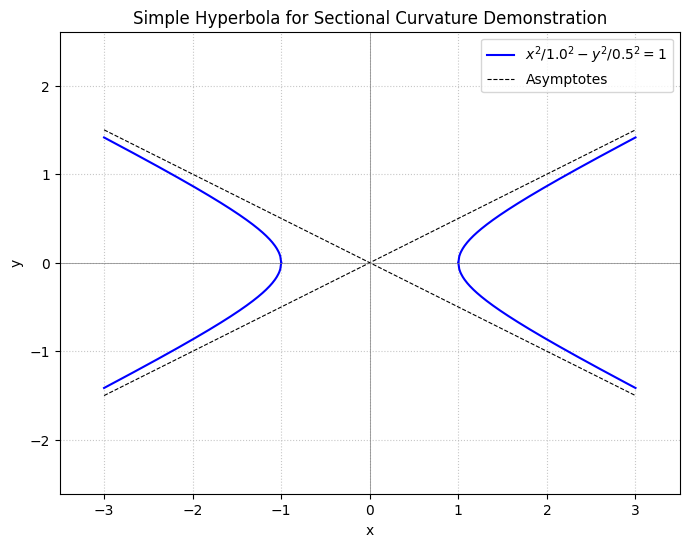

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for the hyperbola
a = 1.0  # Semi-major axis
b = 0.5  # Semi-minor axis

# Generate x values for the hyperbola branches
# x must be greater than or equal to 'a' for the real part of the hyperbola
x_vals_positive = np.linspace(a, 3 * a, 200)
x_vals_negative = np.linspace(-3 * a, -a, 200)

# Calculate y values for the hyperbola branches
# y^2/b^2 = x^2/a^2 - 1
# y = +/- b * sqrt(x^2/a^2 - 1)

y_vals_pos_branch_upper = b * np.sqrt(x_vals_positive**2 / a**2 - 1)
y_vals_pos_branch_lower = -b * np.sqrt(x_vals_positive**2 / a**2 - 1)

y_vals_neg_branch_upper = b * np.sqrt(x_vals_negative**2 / a**2 - 1)
y_vals_neg_branch_lower = -b * np.sqrt(x_vals_negative**2 / a**2 - 1)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the positive x-branch
plt.plot(x_vals_positive, y_vals_pos_branch_upper, color='blue', label=f'$x^2/{a}^2 - y^2/{b}^2 = 1$')
plt.plot(x_vals_positive, y_vals_pos_branch_lower, color='blue')

# Plot the negative x-branch
plt.plot(x_vals_negative, y_vals_neg_branch_upper, color='blue')
plt.plot(x_vals_negative, y_vals_neg_branch_lower, color='blue')

# Add asymptotes for context (y = +/- (b/a)x)
x_asymptote = np.linspace(-3 * a, 3 * a, 200)
y_asymptote_upper = (b / a) * x_asymptote
y_asymptote_lower = -(b / a) * x_asymptote
plt.plot(x_asymptote, y_asymptote_upper, 'k--', linewidth=0.8, label='Asymptotes')
plt.plot(x_asymptote, y_asymptote_lower, 'k--', linewidth=0.8)

# Add grid, labels, title, and legend
plt.axvline(0, color='gray', linewidth=0.5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Hyperbola for Sectional Curvature Demonstration')
plt.legend()
plt.axis('equal') # Ensure the aspect ratio is equal for a proper view
plt.xlim([-3.5 * a, 3.5 * a])
plt.ylim([-3.5 * b, 3.5 * b])
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

DTYPE = np.float64
EPS = 1e-12

def _check_c(c):
    c = float(c)
    if not np.isfinite(c) or c <= 0:
        raise ValueError("c must be finite and positive")
    return c

def inside_ball(x, c, margin=0.0):
    """Whether Euclidean coordinates x lie inside D_c^n."""
    c = _check_c(c)
    return np.linalg.norm(np.asarray(x, dtype=DTYPE)) < (1.0 - margin) / np.sqrt(c)

def project(x, c, eps=1e-7):
    """Radially project Euclidean coordinates into D_c^n."""
    c = _check_c(c)
    x = np.asarray(x, dtype=DTYPE)
    norm = np.linalg.norm(x)
    max_norm = (1.0 - eps) / np.sqrt(c)
    return x if norm <= max_norm or norm == 0.0 else x * (max_norm / norm)

def mobius_add(u, v, c):
    """Möbius addition u ⊕_c v for coordinates in D_c^n."""
    c = _check_c(c)
    u, v = np.asarray(u, dtype=DTYPE), np.asarray(v, dtype=DTYPE)
    if not inside_ball(u, c) or not inside_ball(v, c):
        raise ValueError("Möbius-add inputs must be inside D_c^n")
    uv, u2, v2 = u @ v, u @ u, v @ v
    denominator = 1 + 2*c*uv + c*c*u2*v2
    if denominator <= EPS:
        raise FloatingPointError("Möbius-add denominator is too small")
    return ((1 + 2*c*uv + c*v2)*u + (1 - c*u2)*v) / denominator

def mobius_scalar_mul(t, x, c):
    """Möbius scalar product t ⊗_c x in D_c^n."""
    c = _check_c(c)
    x = np.asarray(x, dtype=DTYPE)
    norm = np.linalg.norm(x)
    if norm == 0.0:
        return np.zeros_like(x)
    z = np.clip(np.sqrt(c)*norm, 0.0, 1.0 - EPS)
    return np.tanh(float(t)*np.arctanh(z)) * x / (np.sqrt(c)*norm)

def poincare_distance(u, v, c):
    """Geodesic distance between Euclidean coordinates u,v in D_c^n."""
    c = _check_c(c)
    delta = mobius_add(-np.asarray(u, dtype=DTYPE), v, c)
    z = np.clip(np.sqrt(c)*np.linalg.norm(delta), 0.0, 1.0 - EPS)
    return 2.0*np.arctanh(z)/np.sqrt(c)

def expmap0(w, c):
    """exp_0^c: tangent coordinates T_0 D_c^n -> D_c^n."""
    c = _check_c(c)
    w = np.asarray(w, dtype=DTYPE)
    norm = np.linalg.norm(w)
    return np.zeros_like(w) if norm == 0.0 else np.tanh(np.sqrt(c)*norm)*w/(np.sqrt(c)*norm)

def logmap0(x, c):
    """log_0^c: D_c^n -> tangent coordinates T_0 D_c^n."""
    c = _check_c(c)
    x = np.asarray(x, dtype=DTYPE)
    if not inside_ball(x, c):
        raise ValueError("log-map input must be inside D_c^n")
    norm = np.linalg.norm(x)
    if norm == 0.0:
        return np.zeros_like(x)
    z = np.clip(np.sqrt(c)*norm, 0.0, 1.0 - EPS)
    return np.arctanh(z)*x/(np.sqrt(c)*norm)

def geodesic(u, v, c, samples=100):
    """Samples gamma(t)=u ⊕_c (t ⊗_c ((-u) ⊕_c v)), t in [0,1]."""
    relative = mobius_add(-np.asarray(u, dtype=DTYPE), v, c)
    return np.array([mobius_add(u, mobius_scalar_mul(t, relative, c), c)
                     for t in np.linspace(0.0, 1.0, samples)])


## Deterministic sanity tests / Детерминированные проверки

The tests cover identity, symmetry, positivity, exp/log round trip, projection, boundary growth, geodesic endpoints and constant-speed behavior, and the declared Euclidean limit. / Тесты проверяют тождество, симметрию, положительность, round-trip exp/log, проекцию, рост у границы, концы и постоянную скорость геодезической и заявленный евклидов предел.

In [3]:
def poincare_distance(u, v, eps=1e-12):
    """Distance in the unit-curvature Poincaré ball."""
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    u2, v2 = u @ u, v @ v
    if u2 >= 1 or v2 >= 1:
        raise ValueError("Points must be strictly inside the unit ball")
    argument = 1 + 2 * np.sum((u - v) ** 2) / ((1 - u2) * (1 - v2))
    return np.arccosh(max(1.0, argument - eps))

origin = np.zeros(2)
for radius in (0.2, 0.5, 0.8, 0.95):
    print(f"radius={radius:.2f}, distance from center={poincare_distance(origin, [radius, 0]):.3f}")

assert np.isclose(poincare_distance(origin, origin), 0.0)
assert poincare_distance(origin, [0.8, 0]) > poincare_distance(origin, [0.5, 0])


radius=0.20, distance from center=0.405
radius=0.50, distance from center=1.099
radius=0.80, distance from center=2.197
radius=0.95, distance from center=3.664


## True Poincaré geodesics / Настоящие геодезические Пуанкаре

Edges below use Möbius geodesic interpolation, not straight visual-aid chords. In this two-dimensional conformal model, non-diameter geodesics appear as boundary-orthogonal circular arcs. / Рёбра ниже построены интерполяцией Мёбиуса, а не вспомогательными прямыми хордами. В двумерной конформной модели геодезические вне диаметров выглядят как дуги, ортогональные границе.

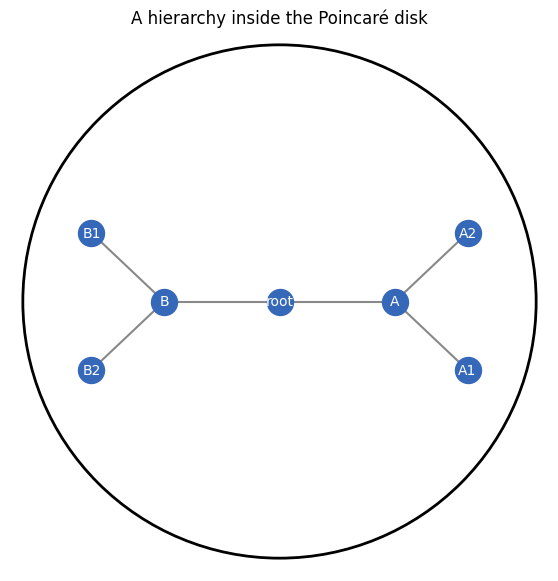

root → A : 0.969
root → B : 0.969
   A → A1: 1.299
   A → A2: 1.299
   B → B1: 1.299
   B → B2: 1.299


In [4]:
levels = {
    "root": (0, 0.0, 0.0),
    "A": (1, 0.45, 0.0), "B": (1, 0.45, np.pi),
    "A1": (2, 0.78, -0.35), "A2": (2, 0.78, 0.35),
    "B1": (2, 0.78, np.pi - 0.35), "B2": (2, 0.78, np.pi + 0.35),
}
points = {name: np.array([radius * np.cos(angle), radius * np.sin(angle)])
          for name, (_, radius, angle) in levels.items()}
edges = [("root", "A"), ("root", "B"), ("A", "A1"), ("A", "A2"),
         ("B", "B1"), ("B", "B2")]

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Circle((0, 0), 1, fill=False, linewidth=2, color="black"))
for source, target in edges:
    # Chords aid readability; true Poincaré geodesics are generally circular arcs.
    xy = np.vstack([points[source], points[target]])
    ax.plot(xy[:, 0], xy[:, 1], color="#888888", zorder=1)
for name, point in points.items():
    ax.scatter(*point, s=350, color="#3568b8", zorder=2)
    ax.text(*point, name, ha="center", va="center", color="white", zorder=3)
ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect="equal",
       title="A hierarchy inside the Poincaré disk")
ax.axis("off")
plt.show()

for source, target in edges:
    print(f"{source:>4} → {target:<2}: {poincare_distance(points[source], points[target]):.3f}")
assert all(np.linalg.norm(point) < 1 for point in points.values())


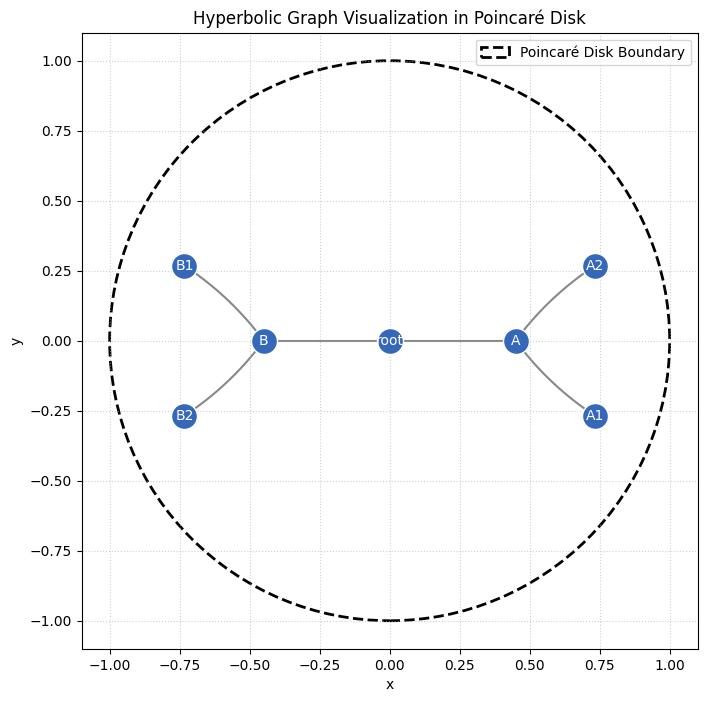

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Curvature from previous cells
c = 1.0 # K = -c

levels = {
    "root": (0, 0.0, 0.0),
    "A": (1, 0.45, 0.0), "B": (1, 0.45, np.pi),
    "A1": (2, 0.78, -0.35), "A2": (2, 0.78, 0.35),
    "B1": (2, 0.78, np.pi - 0.35), "B2": (2, 0.78, np.pi + 0.35),
}
points = {name: np.array([radius * np.cos(angle), radius * np.sin(angle)])
          for name, (_, radius, angle) in levels.items()}
edges = [("root", "A"), ("root", "B"), ("A", "A1"), ("A", "A2"),
         ("B", "B1"), ("B", "B2") ]

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the Poincaré disk boundary
ax.add_patch(plt.Circle((0, 0), 1/np.sqrt(c), fill=False, linewidth=2, color="black", linestyle='--', label='Poincaré Disk Boundary'))

# Plot hyperbolic geodesics for edges
for source, target in edges:
    u = points[source]
    v = points[target]

    # Generate geodesic points
    geodesic_points = geodesic(u, v, c, samples=50)
    ax.plot(geodesic_points[:, 0], geodesic_points[:, 1], color="#888888", zorder=1, linewidth=1.5)

# Plot the nodes
for name, point in points.items():
    ax.scatter(*point, s=350, color="#3568b8", zorder=2, edgecolor='white', linewidth=1)
    ax.text(*point, name, ha="center", va="center", color="white", zorder=3, fontsize=10)

ax.set_title("Hyperbolic Graph Visualization in Poincaré Disk")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Set limits slightly larger than the disk boundary for better visualization
disk_radius = 1.0 / np.sqrt(c)
ax.set_xlim([-disk_radius * 1.1, disk_radius * 1.1])
ax.set_ylim([-disk_radius * 1.1, disk_radius * 1.1])
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle=':', alpha=0.6)

plt.legend()
plt.show()

## Interpretation / Интерпретация

Euclidean radii are bounded by 1, but hyperbolic distance to the boundary is unbounded. The straight edge chords above are visual aids, not generally geodesics. / Евклидовы радиусы ограничены единицей, но гиперболическое расстояние до границы не ограничено. Прямые рёбра на рисунке — визуальная подсказка, а не геодезические.

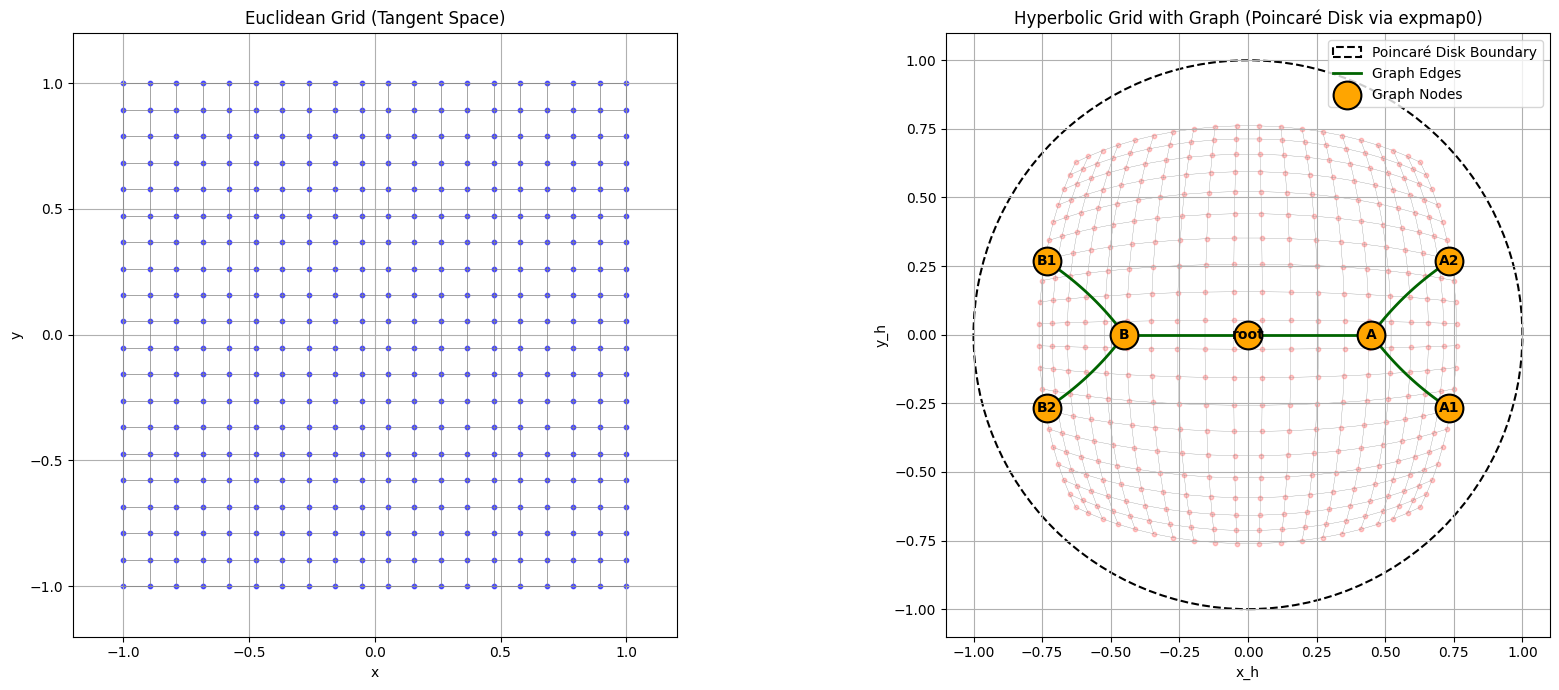


Sample Point: (x_e, y_e) -> (x_h, y_h) -> (x_e_reconstructed, y_e_reconstructed)
Original Euclidean point for sample: [-1.          0.57894737]
Transformed Hyperbolic point: [-0.70927561  0.41063325]
Reconstructed Euclidean point (via logmap0): [-1.          0.57894737]

Verification of expmap0 and logmap0 as inverse maps:
Original Euclidean Test Point: [0.5 0.3]
After expmap0: [0.45010784 0.27006471]
After logmap0 (reconstructed): [0.5 0.3]
Are they close? True


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming DTYPE, EPS, expmap0, logmap0 are defined in previous cells
# (They were executed in cell 2WoD4wCsf0i_)

# Define the curvature parameter c
c = 1.0 # Curvature K = -c

# --- 1. Euclidean Grid (Tangent Space at Origin) ---
# Create a grid of points in a Euclidean space (e.g., a square)
n_points = 20
lin_space = np.linspace(-1.0, 1.0, n_points)
X_euclidean, Y_euclidean = np.meshgrid(lin_space, lin_space)

euclidean_points = np.vstack([X_euclidean.ravel(), Y_euclidean.ravel()]).T

# --- 2. Transform Euclidean to Hyperbolic (Poincaré Disk) using expmap0 ---
# expmap0 maps points from the tangent space at the origin (Euclidean-like) to the Poincaré disk
hyperbolic_points = np.array([expmap0(p, c) for p in euclidean_points])

X_hyperbolic = hyperbolic_points[:, 0].reshape(n_points, n_points)
Y_hyperbolic = hyperbolic_points[:, 1].reshape(n_points, n_points)

# --- 3. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Increased figsize for better visibility with graph

# Plot Euclidean Grid
ax = axes[0]
ax.scatter(euclidean_points[:, 0], euclidean_points[:, 1], s=10, color='blue', alpha=0.6)
for i in range(n_points):
    ax.plot(X_euclidean[i, :], Y_euclidean[i, :], color='gray', linestyle='-', linewidth=0.5)
    ax.plot(X_euclidean[:, i], Y_euclidean[:, i], color='gray', linestyle='-', linewidth=0.5)
ax.set_title('Euclidean Grid (Tangent Space)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

# Plot Hyperbolic Grid (Poincaré Disk Model) and the user's graph
ax = axes[1]
# Plot the unit disk boundary
circle = plt.Circle((0, 0), 1/np.sqrt(c), color='black', fill=False, linestyle='--', linewidth=1.5, label='Poincaré Disk Boundary')
ax.add_patch(circle)

# Plot the hyperbolic grid points and lines (made semi-transparent to allow graph to stand out)
ax.scatter(hyperbolic_points[:, 0], hyperbolic_points[:, 1], s=10, color='red', alpha=0.2, zorder=0)
for i in range(n_points):
    ax.plot(X_hyperbolic[i, :], Y_hyperbolic[i, :], color='gray', linestyle='-', linewidth=0.2, zorder=0)
    ax.plot(X_hyperbolic[:, i], Y_hyperbolic[:, i], color='gray', linestyle='-', linewidth=0.2, zorder=0)

# --- Add the user's graph visualization ---
# Graph definition
levels = {
    "root": (0, 0.0, 0.0),
    "A": (1, 0.45, 0.0), "B": (1, 0.45, np.pi),
    "A1": (2, 0.78, -0.35), "A2": (2, 0.78, 0.35),
    "B1": (2, 0.78, np.pi - 0.35), "B2": (2, 0.78, np.pi + 0.35),
}
# Convert levels (polar coordinates) to Cartesian points in the Poincaré disk
graph_points = {name: np.array([radius * np.cos(angle), radius * np.sin(angle)])
          for name, (_, radius, angle) in levels.items()}
graph_edges = [("root", "A"), ("root", "B"), ("A", "A1"), ("A", "A2"),
         ("B", "B1"), ("B", "B2")]

# Plot hyperbolic geodesics for graph edges
for i, (source, target) in enumerate(graph_edges):
    u = graph_points[source]
    v = graph_points[target]

    # Generate geodesic points
    geodesic_points = geodesic(u, v, c, samples=50)
    # Add label only once for edges
    label_edge = 'Graph Edges' if i == 0 else ''
    ax.plot(geodesic_points[:, 0], geodesic_points[:, 1], color="darkgreen", zorder=2, linewidth=2, label=label_edge)

# Plot the graph nodes
for i, (name, point) in enumerate(graph_points.items()):
    # Add label only once for nodes
    label_node = 'Graph Nodes' if i == 0 else ''
    ax.scatter(*point, s=400, color="orange", zorder=3, edgecolor='black', linewidth=1.5, label=label_node)
    ax.text(*point, name, ha="center", va="center", color="black", zorder=4, fontsize=10, fontweight='bold')

ax.set_title('Hyperbolic Grid with Graph (Poincaré Disk via expmap0)')
ax.set_xlabel('x_h')
ax.set_ylabel('y_h')
# Set limits slightly larger than the disk boundary for better visualization
disk_radius = 1.0 / np.sqrt(c)
ax.set_xlim([-disk_radius * 1.1, disk_radius * 1.1])
ax.set_ylim([-disk_radius * 1.1, disk_radius * 1.1])
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# --- Conceptual Inverse Transform (Hyperbolic to Euclidean) ---
# Let's pick a single point in the hyperbolic space and map it back
# This demonstrates the logmap0 which is the inverse of expmap0 at the origin

# Choose a point from the hyperbolic grid (e.g., the one near the edge)
sample_hyperbolic_point = hyperbolic_points[int(len(hyperbolic_points) * 0.75)]
conceptual_euclidean_point = logmap0(sample_hyperbolic_point, c)

print(f"\nSample Point: (x_e, y_e) -> (x_h, y_h) -> (x_e_reconstructed, y_e_reconstructed)")
print(f"Original Euclidean point for sample: {euclidean_points[int(len(euclidean_points) * 0.75)]}")
print(f"Transformed Hyperbolic point: {sample_hyperbolic_point}")
print(f"Reconstructed Euclidean point (via logmap0): {conceptual_euclidean_point}")

# Verify that logmap0 is the inverse of expmap0 (at the origin)
# If you take an original Euclidean point 'p_euclidean' and do expmap0(p_euclidean, c),
# then applying logmap0 to the result should give back p_euclidean.
original_test_point = np.array([0.5, 0.3]) # A point in the Euclidean tangent space
forward_mapped = expmap0(original_test_point, c)
backward_mapped = logmap0(forward_mapped, c)

print(f"\nVerification of expmap0 and logmap0 as inverse maps:")
print(f"Original Euclidean Test Point: {original_test_point}")
print(f"After expmap0: {forward_mapped}")
print(f"After logmap0 (reconstructed): {backward_mapped}")
print(f"Are they close? {np.allclose(original_test_point, backward_mapped)}")